In [ ]:
# ============================================================================
# ЯЧЕЙКА 0: КОНФИГУРАЦИЯ ЭКСПЕРИМЕНТА (только простые переменные)
# ============================================================================
N_DIM = 4   # размерность (можно 2,4,6,8...)

# Границы интегрирования
a_orig_global = [50.0, 1.0, 0.0, -30.0]
b_orig_global = [300.0, 7.0, 720.0, 30.0]

a_train_global = [30.0, 1.0, 0.0, -30.0]
b_train_global = [400.0, 7.0, 720.0, 30.0]

# Параметры обучения
N_POINTS_TRAIN = 500000
BATCH_SIZE = 512
EPOCHS = 150
VALIDATION_SPLIT = 0.15

# Параметры поиска ρ (используем список, не требующий numpy)
RHO_VALUES = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
RHO_SEARCH_POINTS = 30000
RHO_EPOCHS = 15
RHO_NEURONS = 64

# Параметры тестирования
TEST_PRICE_RANGES = [(50,300), (100,200), (200,400), (30,100), (150,180), (80,250)]
N_MC_POINTS = 50000
N_REFERENCE_POINTS = 200000

print("✅ Конфигурация загружена")

In [ ]:
# ============================================================================
# ЯЧЕЙКА 1: ИМПОРТЫ И НАСТРОЙКИ
# ============================================================================
import numpy as np
import matplotlib.pyplot as plt
import time
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input, BatchNormalization, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.preprocessing import StandardScaler
from scipy.stats import qmc
import warnings
import pickle
import json
from pathlib import Path

warnings.filterwarnings('ignore')
tf.keras.backend.set_floatx('float64')
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Преобразуем конфигурационные списки в массивы numpy
a_orig_global = np.array(a_orig_global[:N_DIM], dtype=float)
b_orig_global = np.array(b_orig_global[:N_DIM], dtype=float)
a_train_global = np.array(a_train_global[:N_DIM], dtype=float)
b_train_global = np.array(b_train_global[:N_DIM], dtype=float)

MODEL_DIR = Path('./nni_saved_models')
MODEL_DIR.mkdir(exist_ok=True)

print(f"Размерность: {N_DIM}")
print(f"Обучение на: {a_train_global} → {b_train_global}")

In [ ]:
# ============================================================================
# ЯЧЕЙКА 2: ФУНКЦИЯ ВЫРУЧКИ И ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ
# ============================================================================
def aviation_revenue(X):
    X = np.atleast_2d(X)
    price = X[:, 0]
    base = 1000.0 * np.exp(-0.01 * price)
    f_day = 1.0 + 0.3 * np.sin((X[:, 1] - 1) * np.pi / 3.5) if N_DIM >= 2 else 1.0
    f_hour = 1.0 + 0.5 * np.exp(-X[:, 2] / 200.0) if N_DIM >= 3 else 1.0
    f_holiday = 1.0 + 0.4 * np.exp(-np.abs(X[:, 3]) / 10.0) if N_DIM >= 4 else 1.0
    product = base * f_day * f_hour * f_holiday
    for i in range(4, N_DIM):
        product *= (1.0 + 0.1 * X[:, i])
    return price * product

def reference_sobol_integral(a_range, b_range, n_points=N_REFERENCE_POINTS):
    vol = np.prod(b_range - a_range)
    sampler = qmc.Sobol(d=len(a_range), scramble=True, seed=SEED)
    pts = sampler.random(n_points)
    pts_scaled = qmc.scale(pts, a_range, b_range)
    I = vol * np.mean(aviation_revenue(pts_scaled))
    return I

print(" Функции определены")

In [ ]:
# ============================================================================
# ЯЧЕЙКА 3: ПОСТРОЕНИЕ ГЛУБОКОЙ НЕЙРОСЕТИ (ПРЯМОЙ NNI)
# ============================================================================
def build_deep_nn(input_dim):
    inputs = Input(shape=(input_dim,))
    x = Dense(1024, activation='swish')(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.1)(x)
    x = Dense(512, activation='swish')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.1)(x)
    x = Dense(256, activation='swish')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.05)(x)
    x = Dense(128, activation='swish')(x)
    x = BatchNormalization()(x)
    x = Dense(64, activation='swish')(x)
    outputs = Dense(1, activation='linear')(x)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

print(" Архитектура сети определена")

In [ ]:
# ============================================================================
# ЯЧЕЙКА 4a: ПОИСК ОПТИМАЛЬНОГО ρ (адаптивная выборка)
# ============================================================================
print(" Поиск оптимального ρ...")

# Фиксированная валидационная выборка
X_val = np.random.uniform(a_train_global, b_train_global, (5000, N_DIM))
y_val = aviation_revenue(X_val).reshape(-1, 1)

best_rho = None
best_mae = float('inf')
results = {}

for rho in RHO_VALUES:
    print(f"Тестирование ρ = {rho:.1f}...", end=" ")
    # Генерация выборки с адаптацией
    X_raw = np.random.uniform(a_train_global, b_train_global, (RHO_SEARCH_POINTS, N_DIM))
    y_raw = aviation_revenue(X_raw).reshape(-1, 1)
    if rho > 0:
        weights = np.abs(y_raw.flatten()) ** rho
        weights /= weights.sum()
        idx = np.random.choice(len(X_raw), size=len(X_raw), p=weights)
        X_raw = X_raw[idx]
        y_raw = y_raw[idx]
    # Нормализация
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()
    X_train = scaler_X.fit_transform(X_raw)
    y_train = scaler_y.fit_transform(y_raw).flatten()
    X_val_scaled = scaler_X.transform(X_val)
    y_val_scaled = scaler_y.transform(y_val).flatten()
    # Маленькая сеть для оценки
    inputs = Input(shape=(N_DIM,))
    x = Dense(RHO_NEURONS, activation='swish')(inputs)
    outputs = Dense(1, activation='linear')(x)
    tmp_model = Model(inputs, outputs)
    tmp_model.compile(optimizer=Adam(0.001), loss='mse')
    tmp_model.fit(X_train, y_train, batch_size=512, epochs=RHO_EPOCHS, verbose=0)
    y_pred = tmp_model.predict(X_val_scaled, verbose=0).flatten()
    mae = np.mean(np.abs(y_val_scaled - y_pred))
    results[rho] = mae
    print(f"MAE = {mae:.6f}")
    if mae < best_mae:
        best_mae = mae
        best_rho = rho

print(f"\n Оптимальное ρ = {best_rho:.1f} (MAE = {best_mae:.6f})")

# Визуализация
plt.figure(figsize=(10,5))
plt.plot(list(results.keys()), list(results.values()), 'bo-')
plt.axvline(best_rho, color='r', linestyle='--', label=f'Оптимум ρ={best_rho:.1f}')
plt.xlabel('ρ')
plt.ylabel('MAE')
plt.title('Поиск оптимального ρ для адаптивной выборки')
plt.legend()
plt.grid(True)
plt.savefig(MODEL_DIR / 'rho_search.png', dpi=150)
plt.show()

# Сохраняем результат
with open(MODEL_DIR / 'best_rho.txt', 'w') as f:
    f.write(str(best_rho))
print(f" Оптимальное ρ сохранено в {MODEL_DIR / 'best_rho.txt'}")

In [12]:
# ============================================================================
# ЯЧЕЙКА 4b: ОБУЧЕНИЕ ИЛИ ЗАГРУЗКА ФИНАЛЬНОЙ МОДЕЛИ С НАЙДЕННЫМ ρ
# ============================================================================
# Загружаем оптимальное ρ
try:
    with open(MODEL_DIR / 'best_rho.txt', 'r') as f:
        best_rho = float(f.read().strip())
    print(f"✅ Загружено оптимальное ρ = {best_rho:.1f}")
except:
    print("⚠️ Файл best_rho.txt не найден, используем ρ = 0.5")
    best_rho = 0.5

# Детерминированное имя модели (без timestamp)
model_name = f'deep_nni_{N_DIM}d_rho{best_rho:.1f}'
model_path = MODEL_DIR / f'{model_name}.keras'
scaler_X_path = MODEL_DIR / f'{model_name}_scaler_X.pkl'
scaler_y_path = MODEL_DIR / f'{model_name}_scaler_y.pkl'

# Проверяем, существует ли уже обученная модель
if model_path.exists() and scaler_X_path.exists() and scaler_y_path.exists():
    print(f"🔄 Найдена сохранённая модель: {model_path}")
    # Загружаем модель и скейлеры
    model = tf.keras.models.load_model(model_path)
    with open(scaler_X_path, 'rb') as f:
        scaler_X = pickle.load(f)
    with open(scaler_y_path, 'rb') as f:
        scaler_y = pickle.load(f)
    print("✅ Модель и скейлеры успешно загружены. Обучение пропущено.")
else:
    print("🚀 Сохранённая модель не найдена. Начинаем обучение с нуля.")
    print(f"📁 Будет создана модель: {model_name}")
    
    # Генерация данных с адаптивной выборкой (если rho > 0)
    print("📊 Генерация обучающих данных...")
    X_raw = np.random.uniform(a_train_global, b_train_global, (N_POINTS_TRAIN, N_DIM))
    y_raw = aviation_revenue(X_raw).reshape(-1, 1)

    if best_rho > 0:
        weights = np.abs(y_raw.flatten()) ** best_rho
        weights /= weights.sum()
        idx = np.random.choice(len(X_raw), size=len(X_raw), p=weights)
        X_raw = X_raw[idx]
        y_raw = y_raw[idx]

    # Добавляем важные области (цены из тестовых диапазонов)
    important_X = []
    for p_min, pmax in TEST_PRICE_RANGES:
        X_region = np.random.uniform(a_train_global, b_train_global, (N_POINTS_TRAIN // 10, N_DIM))
        X_region[:, 0] = np.random.uniform(p_min, pmax, len(X_region))
        important_X.append(X_region)
    X_important = np.vstack(important_X)
    y_important = aviation_revenue(X_important).reshape(-1, 1)

    X_raw = np.vstack([X_raw, X_important])
    y_raw = np.vstack([y_raw, y_important])
    print(f"   Всего точек: {len(X_raw):,}")

    # Нормализация
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()
    X_norm = scaler_X.fit_transform(X_raw)
    y_norm = scaler_y.fit_transform(y_raw).flatten()

    # Сохраняем скейлеры
    with open(scaler_X_path, 'wb') as f:
        pickle.dump(scaler_X, f)
    with open(scaler_y_path, 'wb') as f:
        pickle.dump(scaler_y, f)

    # Создаём и обучаем модель
    model = build_deep_nn(N_DIM)
    print(f" Параметров модели: {model.count_params():,}")

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
        ModelCheckpoint(MODEL_DIR / f'{model_name}_best.keras', monitor='val_loss', save_best_only=True, verbose=0)
    ]

    history = model.fit(X_norm, y_norm,
                        batch_size=BATCH_SIZE,
                        epochs=EPOCHS,
                        validation_split=VALIDATION_SPLIT,
                        callbacks=callbacks,
                        verbose=1)

    # Загружаем лучшие веса и сохраняем финальную модель
    model = tf.keras.models.load_model(MODEL_DIR / f'{model_name}_best.keras')
    model.save(model_path)
    print(f" Модель сохранена: {model_path}")

    # График обучения
    plt.figure(figsize=(12,4))
    plt.subplot(121)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Validation')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid()
    plt.subplot(122) 
    plt.semilogy(history.history['loss'], label='Train')
    plt.semilogy(history.history['val_loss'], label='Validation')
    plt.xlabel('Epoch'); plt.ylabel('Loss (log)'); plt.legend(); plt.grid()
    plt.suptitle(f'Финальное обучение (ρ={best_rho:.1f})')
    plt.tight_layout()
    plt.savefig(MODEL_DIR / f'{model_name}_history.png', dpi=150)
    plt.show()

✅ Загружено оптимальное ρ = 0.2
🔄 Найдена сохранённая модель: nni_saved_models/deep_nni_4d_rho0.2.keras
✅ Модель и скейлеры успешно загружены. Обучение пропущено.


In [13]:
# ============================================================================
# ЯЧЕЙКА 5: ВЫЧИСЛЕНИЕ ИНТЕГРАЛА ЧЕРЕЗ ПРЯМОЙ NNI
# ============================================================================
def nni_integral(a_range, b_range, n_points=N_MC_POINTS):
    vol = np.prod(b_range - a_range)
    dim = len(a_range)
    sampler = qmc.Sobol(d=dim, scramble=True, seed=SEED)
    pts = sampler.random(n_points)
    pts_scaled = qmc.scale(pts, a_range, b_range)
    X_norm = scaler_X.transform(pts_scaled)
    y_pred_norm = model.predict(X_norm, verbose=0).flatten()
    y_pred = scaler_y.inverse_transform(y_pred_norm.reshape(-1, 1)).flatten()
    return vol * np.mean(y_pred)

print(" Функция nni_integral определена")

 Функция nni_integral определена


In [14]:
# ============================================================================
# ЯЧЕЙКА 6: СРАВНЕНИЕ МЕТОДОВ (NNI, MC, Sobol) С ЭТАЛОНОМ
# ============================================================================
import json

# Кэширование эталонов
CACHE_FILE = MODEL_DIR / f'reference_sobol_{N_DIM}d.json'
if CACHE_FILE.exists():
    with open(CACHE_FILE, 'r') as f:
        ref_cache = json.load(f)
    print(" Загружен кэш эталонов")
else:
    ref_cache = {}

def get_reference(a_range, b_range):
    key = str(a_range.tolist()) + str(b_range.tolist())
    if key in ref_cache:
        return ref_cache[key]
    I = reference_sobol_integral(a_range, b_range, N_REFERENCE_POINTS)
    ref_cache[key] = I
    with open(CACHE_FILE, 'w') as f:
        json.dump(ref_cache, f, indent=2)
    return I

def run_comparison(a_range, b_range, n_points=N_MC_POINTS):
    vol = np.prod(b_range - a_range)
    dim = len(a_range)
    # MC
    pts_mc = np.random.uniform(a_range, b_range, (n_points, dim))
    I_mc = vol * np.mean(aviation_revenue(pts_mc))
    # Sobol
    sampler = qmc.Sobol(d=dim, scramble=True, seed=SEED)
    pts_sobol = qmc.scale(sampler.random(n_points), a_range, b_range)
    I_sobol = vol * np.mean(aviation_revenue(pts_sobol))
    return I_mc, I_sobol

# Тестирование
results = []
print("\n" + "="*120)
print(f"{'№':<3} {'price диапазон':<15} {'Эталон':<25} {'NNI':<20} {'NNI err%':<10} {'MC err%':<10} {'Sobol err%':<10}")
print("-"*120)

for i, (pmin, pmax) in enumerate(TEST_PRICE_RANGES):
    a = a_orig_global.copy()
    b = b_orig_global.copy()
    a[0], b[0] = pmin, pmax
    I_ref = get_reference(a, b)
    
    t0 = time.time()
    I_nni = nni_integral(a, b, N_MC_POINTS)
    t_nni = time.time() - t0
    err_nni = abs(I_ref - I_nni) / I_ref * 100
    
    I_mc, I_sobol = run_comparison(a, b, N_MC_POINTS)
    err_mc = abs(I_ref - I_mc) / I_ref * 100
    err_sobol = abs(I_ref - I_sobol) / I_ref * 100
    
    results.append({
        'range': f"[{pmin},{pmax}]", 'true': I_ref, 'nni': I_nni,
        'nni_error': err_nni, 'mc_error': err_mc, 'sobol_error': err_sobol, 'nni_time': t_nni
    })
    print(f"{i+1:<3} {results[-1]['range']:<15} {I_ref:<25,.0f} {I_nni:<20,.0f} {err_nni:<10.4f} {err_mc:<10.4f} {err_sobol:<10.4f}")

print("\n" + "="*120)
print(f"Средняя ошибка NNI:   {np.mean([r['nni_error'] for r in results]):.4f}%")
print(f"Средняя ошибка MC:    {np.mean([r['mc_error'] for r in results]):.4f}%")
print(f"Средняя ошибка Sobol: {np.mean([r['sobol_error'] for r in results]):.4f}%")

 Загружен кэш эталонов

№   price диапазон  Эталон                    NNI                  NNI err%   MC err%    Sobol err%
------------------------------------------------------------------------------------------------------------------------
1   [50,300]        2,405,148,319,324         2,403,554,242,157    0.0663     0.1286     0.0000    
2   [100,200]       1,116,031,303,836         1,116,191,354,230    0.0143     0.1996     0.0001    
3   [200,400]       1,064,163,404,531         1,067,194,076,204    0.2848     0.4023     0.0001    
4   [30,100]        769,300,830,999           769,723,949,574      0.0550     0.1002     0.0003    
5   [150,180]       321,483,497,944           321,496,682,781      0.0041     0.0964     0.0002    
6   [80,250]        1,764,970,291,917         1,764,323,072,479    0.0367     0.1391     0.0000    

Средняя ошибка NNI:   0.0769%
Средняя ошибка MC:    0.1777%
Средняя ошибка Sobol: 0.0001%


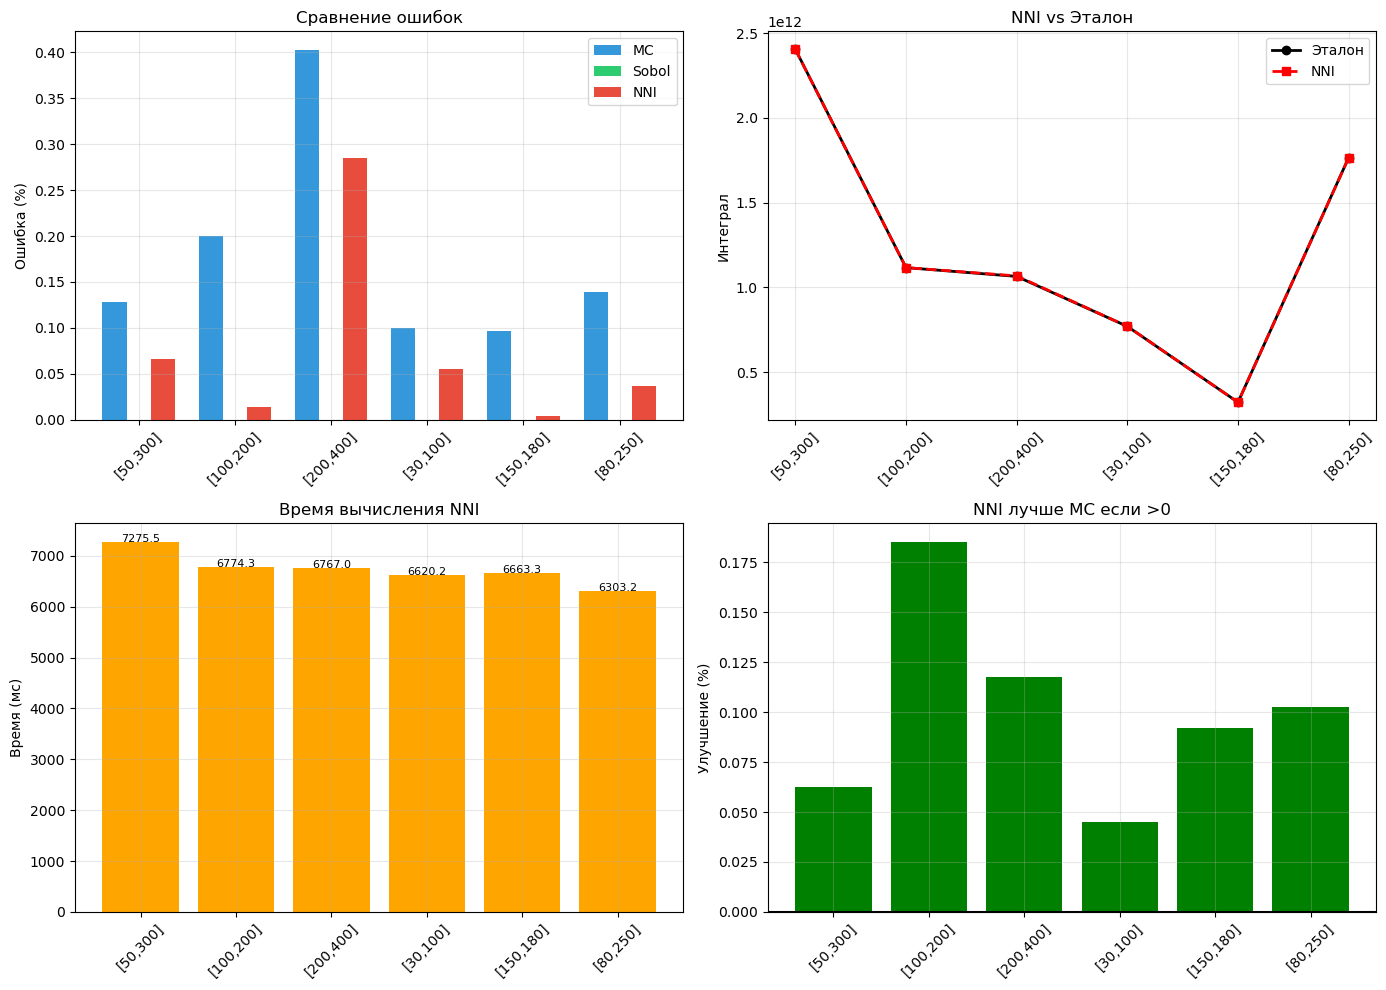

Графики сохранены в nni_saved_models


In [15]:
# ============================================================================
# ЯЧЕЙКА 7: ВИЗУАЛИЗАЦИЯ (графики ошибок и времени)
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
x = np.arange(len(results))
width = 0.25

# Ошибки
ax = axes[0,0]
ax.bar(x - width, [r['mc_error'] for r in results], width, label='MC', color='#3498db')
ax.bar(x, [r['sobol_error'] for r in results], width, label='Sobol', color='#2ecc71')
ax.bar(x + width, [r['nni_error'] for r in results], width, label='NNI', color='#e74c3c')
ax.set_xticks(x); ax.set_xticklabels([r['range'] for r in results], rotation=45)
ax.set_ylabel('Ошибка (%)'); ax.set_title('Сравнение ошибок'); ax.legend(); ax.grid(alpha=0.3)

# Значения
ax = axes[0,1]
ax.plot(x, [r['true'] for r in results], 'ko-', label='Эталон', linewidth=2)
ax.plot(x, [r['nni'] for r in results], 'rs--', label='NNI', linewidth=2)
ax.set_xticks(x); ax.set_xticklabels([r['range'] for r in results], rotation=45)
ax.set_ylabel('Интеграл'); ax.set_title('NNI vs Эталон'); ax.legend(); ax.grid(alpha=0.3)

# Время NNI
ax = axes[1,0]
times = [r['nni_time']*1000 for r in results]
bars = ax.bar(x, times, color='orange')
ax.set_xticks(x); ax.set_xticklabels([r['range'] for r in results], rotation=45)
ax.set_ylabel('Время (мс)'); ax.set_title('Время вычисления NNI'); ax.grid(alpha=0.3)
for bar, t in zip(bars, times):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5, f'{t:.1f}', ha='center', fontsize=8)

# Улучшение NNI над MC
ax = axes[1,1]
impr = [r['mc_error'] - r['nni_error'] for r in results]
colors = ['green' if v>0 else 'red' for v in impr]
ax.bar(x, impr, color=colors)
ax.axhline(0, color='black')
ax.set_xticks(x); ax.set_xticklabels([r['range'] for r in results], rotation=45)
ax.set_ylabel('Улучшение (%)'); ax.set_title('NNI лучше MC если >0'); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(MODEL_DIR / 'comparison_results.png', dpi=150)
plt.show()
print(f"Графики сохранены в {MODEL_DIR}")

In [18]:
# ============================================================================
# ЯЧЕЙКА 8: ЭКСПОРТ РЕЗУЛЬТАТОВ В CSV
# ============================================================================
import pandas as pd
if results:
    df = pd.DataFrame(results)
    csv_path = MODEL_DIR / 'test_results.csv'
    df.to_csv(csv_path, index=False)
    print(f" Результаты сохранены в {csv_path}")
else:
    print("Нет данных для экспорта.")

 Результаты сохранены в nni_saved_models/test_results.csv


✅ Данные о времени уже есть, строим график...


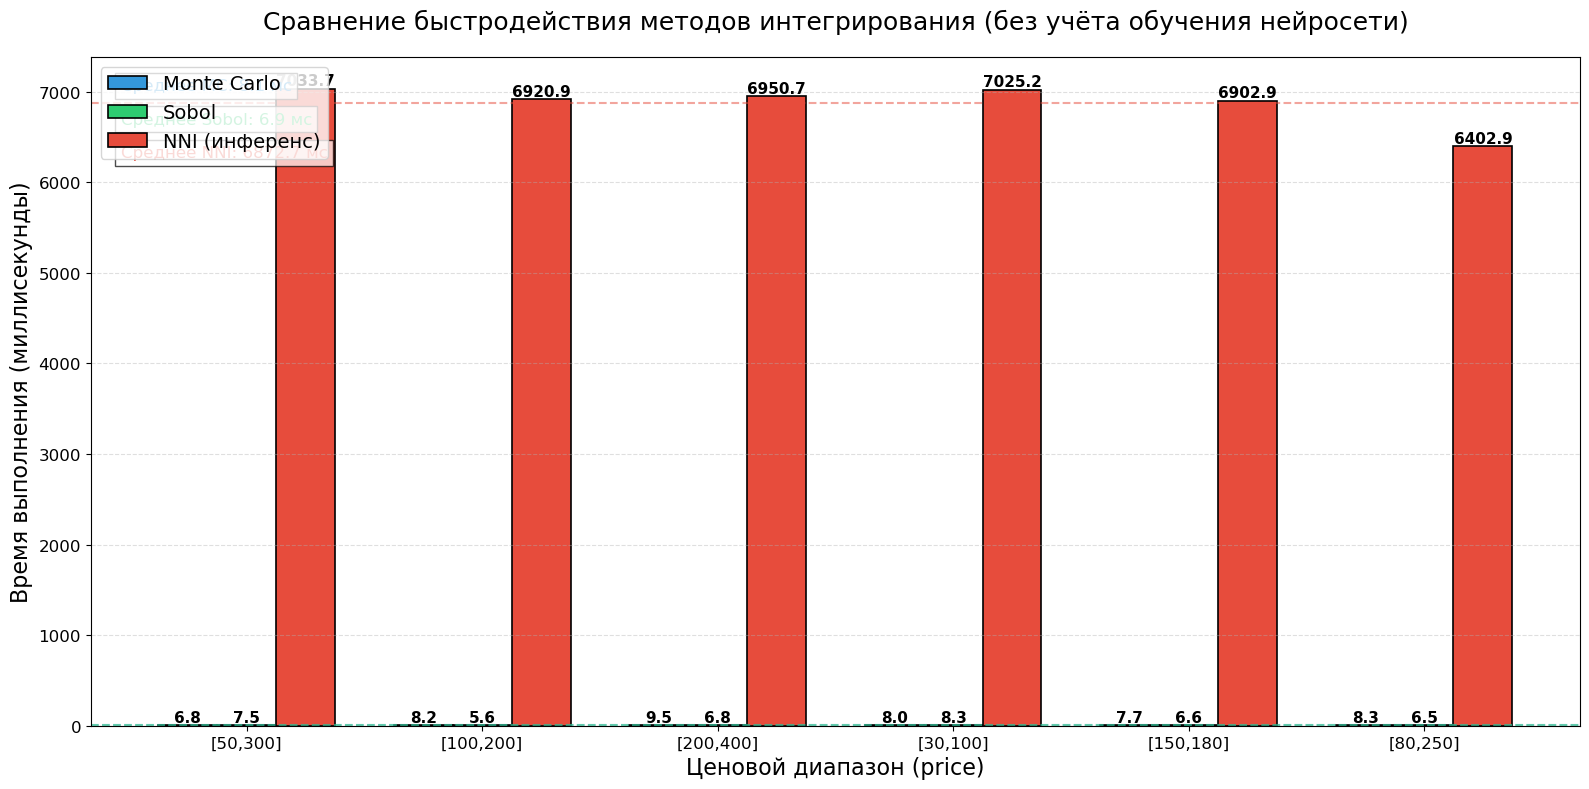


✅ Увеличенный график сохранён: nni_saved_models/time_comparison_large.png

📊 Среднее время (мс):
  MC:    8.09
  Sobol: 6.87
  NNI:   6872.73


In [17]:
# ============================================================================
# ЯЧЕЙКА 9 (новая): СРАВНЕНИЕ ВРЕМЕНИ (УВЕЛИЧЕННЫЙ ГРАФИК, ВСЕ ТРИ МЕТОДА)
# ============================================================================
if 'time_results' not in dir() or time_results is None or len(time_results) == 0:
    print("⏱️ Выполняется замер времени для всех методов (без обучения NNI)...")
    import time
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.stats import qmc

    def time_nni(a, b, n_points=N_MC_POINTS):
        vol = np.prod(b - a)
        dim = len(a)
        sampler = qmc.Sobol(d=dim, scramble=True, seed=SEED)
        pts = sampler.random(n_points)
        pts_scaled = qmc.scale(pts, a, b)
        t0 = time.perf_counter()
        X_norm = scaler_X.transform(pts_scaled)
        y_pred_norm = model.predict(X_norm, verbose=0).flatten()
        y_pred = scaler_y.inverse_transform(y_pred_norm.reshape(-1, 1)).flatten()
        I = vol * np.mean(y_pred)
        elapsed_ms = (time.perf_counter() - t0) * 1000
        return I, elapsed_ms

    def time_mc(a, b, n_points=N_MC_POINTS):
        vol = np.prod(b - a)
        dim = len(a)
        t0 = time.perf_counter()
        pts = np.random.uniform(a, b, (n_points, dim))
        I = vol * np.mean(aviation_revenue(pts))
        elapsed_ms = (time.perf_counter() - t0) * 1000
        return I, elapsed_ms

    def time_sobol(a, b, n_points=N_MC_POINTS):
        vol = np.prod(b - a)
        dim = len(a)
        t0 = time.perf_counter()
        sampler = qmc.Sobol(d=dim, scramble=True, seed=SEED)
        pts = qmc.scale(sampler.random(n_points), a, b)
        I = vol * np.mean(aviation_revenue(pts))
        elapsed_ms = (time.perf_counter() - t0) * 1000
        return I, elapsed_ms

    time_results = []
    for pmin, pmax in TEST_PRICE_RANGES:
        a = a_orig_global.copy()
        b = b_orig_global.copy()
        a[0], b[0] = pmin, pmax
        _, t_nni = time_nni(a, b, N_MC_POINTS)
        _, t_mc = time_mc(a, b, N_MC_POINTS)
        _, t_sobol = time_sobol(a, b, N_MC_POINTS)
        time_results.append({
            'range': f'[{pmin},{pmax}]',
            'nni_ms': t_nni,
            'mc_ms': t_mc,
            'sobol_ms': t_sobol
        })
        print(f"{time_results[-1]['range']:12} | NNI: {t_nni:6.2f} мс | MC: {t_mc:6.2f} мс | Sobol: {t_sobol:6.2f} мс")
else:
    print("✅ Данные о времени уже есть, строим график...")

# ============================================================================
# Построение УВЕЛИЧЕННОГО графика
# ============================================================================
plt.style.use('default')
fig, ax = plt.subplots(figsize=(16, 8))  # Увеличенный размер

x = np.arange(len(time_results))
width = 0.25

# Цвета: MC, Sobol, NNI
bars1 = ax.bar(x - width, [r['mc_ms'] for r in time_results], width, label='Monte Carlo', color='#3498db', edgecolor='black', linewidth=1.2)
bars2 = ax.bar(x, [r['sobol_ms'] for r in time_results], width, label='Sobol', color='#2ecc71', edgecolor='black', linewidth=1.2)
bars3 = ax.bar(x + width, [r['nni_ms'] for r in time_results], width, label='NNI (инференс)', color='#e74c3c', edgecolor='black', linewidth=1.2)

# Подписи столбцов
ax.set_xlabel('Ценовой диапазон (price)', fontsize=16)
ax.set_ylabel('Время выполнения (миллисекунды)', fontsize=16)
ax.set_title('Сравнение быстродействия методов интегрирования (без учёта обучения нейросети)', fontsize=18, pad=20)
ax.set_xticks(x)
ax.set_xticklabels([r['range'] for r in time_results], fontsize=14, rotation=0)
ax.legend(fontsize=14, loc='upper left')
ax.grid(axis='y', alpha=0.4, linestyle='--')
ax.tick_params(axis='both', labelsize=12)

# Добавляем значения НАД столбцами (увеличенный шрифт)
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 3,
                f'{height:.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Дополнительная аннотация по среднему значению
avg_mc = np.mean([r['mc_ms'] for r in time_results])
avg_sobol = np.mean([r['sobol_ms'] for r in time_results])
avg_nni = np.mean([r['nni_ms'] for r in time_results])
ax.axhline(avg_mc, color='#3498db', linestyle='--', alpha=0.5, linewidth=1.5)
ax.axhline(avg_sobol, color='#2ecc71', linestyle='--', alpha=0.5, linewidth=1.5)
ax.axhline(avg_nni, color='#e74c3c', linestyle='--', alpha=0.5, linewidth=1.5)

# Легенда средних значений
ax.text(0.02, 0.95, f'Среднее MC: {avg_mc:.1f} мс', transform=ax.transAxes, fontsize=12, color='#3498db',
        bbox=dict(facecolor='white', alpha=0.7))
ax.text(0.02, 0.90, f'Среднее Sobol: {avg_sobol:.1f} мс', transform=ax.transAxes, fontsize=12, color='#2ecc71',
        bbox=dict(facecolor='white', alpha=0.7))
ax.text(0.02, 0.85, f'Среднее NNI: {avg_nni:.1f} мс', transform=ax.transAxes, fontsize=12, color='#e74c3c',
        bbox=dict(facecolor='white', alpha=0.7))

plt.tight_layout()
plt.savefig(MODEL_DIR / 'time_comparison_large.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"\n✅ Увеличенный график сохранён: {MODEL_DIR / 'time_comparison_large.png'}")
print(f"\n📊 Среднее время (мс):\n  MC:    {avg_mc:.2f}\n  Sobol: {avg_sobol:.2f}\n  NNI:   {avg_nni:.2f}")